# 03 - Embeddings Comparison: Choosing the Right Embedding Model

**Phase 3** of the RAG exploration project. We compare 4 open-source embedding models
that run 100% locally:

1. **all-MiniLM-L6-v2** (sentence-transformers) - 384 dim, ~80MB, fastest
2. **nomic-embed-text** (Ollama) - 768 dim, ~275MB, Ollama-native
3. **BAAI/bge-small-en-v1.5** (sentence-transformers) - 384 dim, ~130MB, strong MTEB
4. **mxbai-embed-large** (Ollama) - 1024 dim, ~670MB, highest quality

For each model we measure:
- **Embedding throughput**: time to embed the full corpus
- **Query latency**: average time to embed a single query
- **Memory / disk usage**: vector store size on disk
- **Retrieval quality**: top score, avg score on benchmark queries
- **Semantic sanity checks**: known-similar and known-dissimilar pairs

We use the **recursive** chunking strategy (chunk_size=1000, overlap=200) from Phase 2
as our fixed corpus.

---

## 0. Setup

In [1]:
import json
import os
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = Path(".").resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.ingestion.loaders import load_documents_from_directory
from src.ingestion.cleaners import clean_corpus
from src.ingestion.chunkers import chunk_recursive
from src.embeddings.models import (
    create_from_registry,
    benchmark_embedding,
    load_model_registry,
    EmbeddingModelInfo,
    filter_chunks_by_max_chars,
    get_strictest_max_chars,
)
from notebooks.utils.display import display_retrieval_results
from notebooks.utils.metrics import benchmark_queries

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 80)

MODELS_YAML = str(PROJECT_ROOT / "configs" / "models.yaml")

print(f"Project root: {PROJECT_ROOT}")

Project root: /home/hunganh/Code/Python/course_qa_assist


## 1. Prepare the Corpus

Load, clean, and chunk with recursive splitting (the Phase 2 baseline).

We then filter out chunks that exceed the context window of the most restrictive model.
The filter uses `max_chars` from `configs/models.yaml` as a first pass, then validates
with the actual model to catch edge cases (CJK characters tokenize into more tokens per
character). This ensures **all models are benchmarked on exactly the same texts**.

In [2]:
docs = load_documents_from_directory(str(PROJECT_ROOT / "data" / "lectures"))
cleaned_docs, clean_stats = clean_corpus(docs, min_content_length=50)

result = chunk_recursive(cleaned_docs, chunk_size=1000, chunk_overlap=200)
all_chunks = result.chunks
print(f"Loaded: {len(docs)} docs -> Cleaned: {len(cleaned_docs)} -> Chunks: {len(all_chunks)}")

# First pass: filter by max_chars from the registry
registry = load_model_registry(MODELS_YAML)
MAX_CHARS = get_strictest_max_chars(list(registry.values()))

print(f"\nModel context limits (max_chars):")
for key, info in registry.items():
    marker = " <- strictest" if info.max_chars == MAX_CHARS else ""
    print(f"  {key:15s}: {info.max_chars:>6} chars ({info.max_tokens} tokens){marker}")

chunks, dropped_chars = filter_chunks_by_max_chars(all_chunks, max_chars=MAX_CHARS)
print(f"\nAfter char filter (max_chars={MAX_CHARS}): {len(chunks)} chunks (dropped {dropped_chars})")

# Second pass: validate "suspect" chunks (high non-ASCII ratio) with mxbai-embed-large.
# CJK characters tokenize into 2-3 tokens each, so a 1000-char chunk with lots of
# CJK can exceed the 512-token context window despite being under 1400 chars.
# We only test suspects (>5% non-ASCII) to keep this fast (~few seconds).
from langchain_ollama import OllamaEmbeddings

_validator = OllamaEmbeddings(model="mxbai-embed-large")

valid_chunks = []
token_dropped = 0
suspects_tested = 0

for c in chunks:
    text = c.page_content
    non_ascii_ratio = sum(1 for ch in text if ord(ch) > 127) / len(text) if text else 0

    if non_ascii_ratio > 0.05:
        suspects_tested += 1
        try:
            _validator.embed_documents([text])
            valid_chunks.append(c)
        except Exception:
            token_dropped += 1
    else:
        valid_chunks.append(c)

del _validator  # free memory

print(f"Validation pass: tested {suspects_tested} suspect chunks (>5% non-ASCII), dropped {token_dropped}")

chunks = valid_chunks
corpus_texts = [c.page_content for c in chunks]

print(f"\nFinal corpus: {len(chunks)} chunks, {sum(len(t) for t in corpus_texts):,} characters total")

Loaded 2703 document pages from /home/hunganh/Code/Python/course_qa_assist/data/lectures
Loaded: 2703 docs -> Cleaned: 2666 -> Chunks: 9137

Model context limits (max_chars):
  nomic_embed    :  24000 chars (8192 tokens)
  minilm         :   1400 chars (256 tokens) <- strictest
  bge_small      :   1400 chars (512 tokens) <- strictest
  mxbai_large    :   1400 chars (512 tokens) <- strictest

After char filter (max_chars=1400): 9137 chunks (dropped 0)
Validation pass: tested 40 suspect chunks (>5% non-ASCII), dropped 1

Final corpus: 9136 chunks, 7,693,436 characters total


---
## 2. Load All Embedding Models

We use the model registry (`configs/models.yaml`) to instantiate each model.

> **Note**: Ollama models (`nomic-embed-text`, `mxbai-embed-large`) require `ollama serve` running.
> Sentence-transformers models are downloaded automatically on first use.

In [3]:
MODEL_KEYS = ["minilm", "nomic_embed", "bge_small", "mxbai_large"]

models = {}
for key in MODEL_KEYS:
    print(f"Loading {key}...", end=" ", flush=True)
    try:
        emb, info = create_from_registry(key, config_path=MODELS_YAML)
        # Warmup: embed one short text to trigger model loading / download
        emb.embed_query("warmup")
        models[key] = {"embeddings": emb, "info": info}
        print(f"OK ({info.provider}, {info.dimensions}d, max_chars={info.max_chars})")
    except Exception as e:
        print(f"FAILED: {e}")

print(f"\n{len(models)}/{len(MODEL_KEYS)} models loaded successfully.")

Loading minilm... 

/home/hunganh/Code/Python/course_qa_assist/src/embeddings/models.py:161: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  return HuggingFaceEmbeddings(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


OK (sentence-transformers, 384d, max_chars=1400)
Loading nomic_embed... OK (ollama, 768d, max_chars=24000)
Loading bge_small... 

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


OK (sentence-transformers, 384d, max_chars=1400)
Loading mxbai_large... OK (ollama, 1024d, max_chars=1400)

4/4 models loaded successfully.


---
## 3. Embedding Throughput Benchmark

We embed a **sample** of the corpus (500 chunks) and measure total time and per-query latency.
Full corpus embedding is done later during indexing (section 5).

In [4]:
import random

random.seed(42)
SAMPLE_SIZE = 500
sample_texts = random.sample(corpus_texts, min(SAMPLE_SIZE, len(corpus_texts)))

BENCH_QUERIES = [
    "How do I create a basic RAG chain in LangChain?",
    "What is an Embedding model?",
    "How does RecursiveCharacterTextSplitter work?",
    "What are the different types of memory in LangChain?",
    "How do I use Ollama with LangChain?",
]

benchmarks = {}

for key, m in models.items():
    print(f"Benchmarking {key} ({len(sample_texts)} texts, {len(BENCH_QUERIES)} queries)...", flush=True)
    bench = benchmark_embedding(
        m["embeddings"],
        sample_texts,
        BENCH_QUERIES,
        model_name=key,
    )
    benchmarks[key] = bench
    print(f"  Corpus: {bench.embed_corpus_time_s:.1f}s | Avg query: {bench.avg_query_latency_ms:.1f}ms")
    print(f"  Embedded: {bench.num_documents}/{len(sample_texts)} texts")

# Summary table
bench_rows = []
for key, bench in benchmarks.items():
    info = models[key]["info"]
    bench_rows.append({
        "model": key,
        "provider": info.provider,
        "dimensions": info.dimensions,
        "embedded": bench.num_documents,
        "corpus_time_s": round(bench.embed_corpus_time_s, 2),
        "docs_per_sec": round(bench.num_documents / bench.embed_corpus_time_s, 1) if bench.embed_corpus_time_s > 0 else 0,
        "avg_query_ms": round(bench.avg_query_latency_ms, 1),
    })

bench_df = pd.DataFrame(bench_rows).set_index("model")
print("\nThroughput Summary:")
display(bench_df)

Benchmarking minilm (500 texts, 5 queries)...
  Corpus: 9.0s | Avg query: 18.1ms
  Embedded: 500/500 texts
Benchmarking nomic_embed (500 texts, 5 queries)...
  Corpus: 4.6s | Avg query: 61.4ms
  Embedded: 500/500 texts
Benchmarking bge_small (500 texts, 5 queries)...
  Corpus: 22.2s | Avg query: 17.6ms
  Embedded: 500/500 texts
Benchmarking mxbai_large (500 texts, 5 queries)...
  Corpus: 7.2s | Avg query: 21.8ms
  Embedded: 500/500 texts

Throughput Summary:


,provider,dimensions,embedded,corpus_time_s,docs_per_sec,avg_query_ms
model,,,,,,
minilm,sentence-transformers,384,500,8.96,55.8,18.1
nomic_embed,ollama,768,500,4.58,109.3,61.4
bge_small,sentence-transformers,384,500,22.19,22.5,17.6
mxbai_large,ollama,1024,500,7.20,69.4,21.8


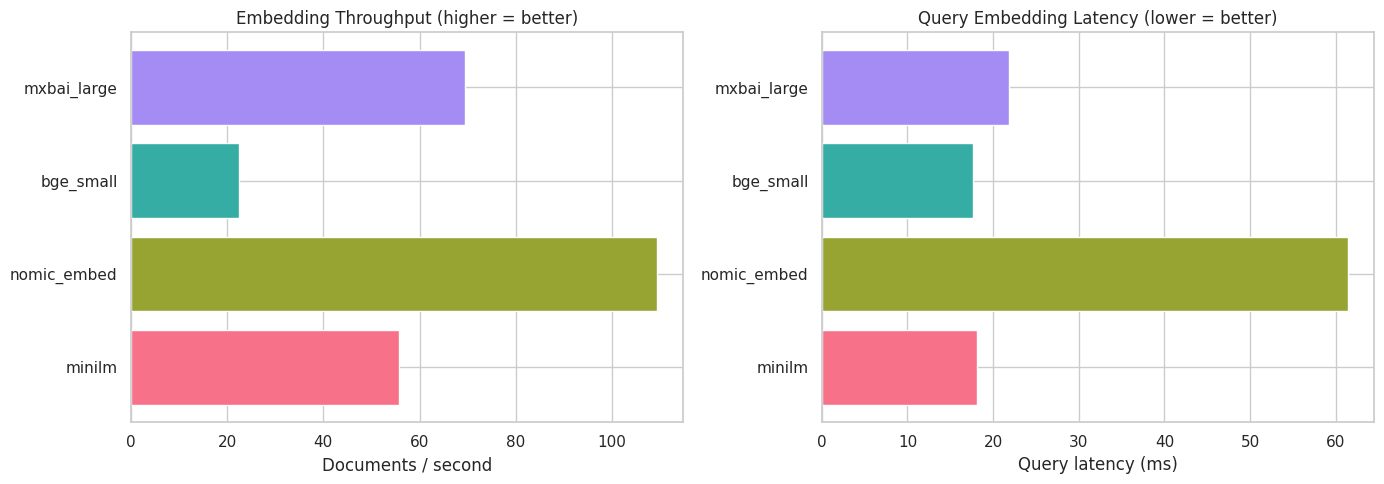

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = sns.color_palette("husl", len(bench_df))
model_names = bench_df.index.tolist()

axes[0].barh(model_names, bench_df["docs_per_sec"], color=colors)
axes[0].set_xlabel("Documents / second")
axes[0].set_title("Embedding Throughput (higher = better)")

axes[1].barh(model_names, bench_df["avg_query_ms"], color=colors)
axes[1].set_xlabel("Query latency (ms)")
axes[1].set_title("Query Embedding Latency (lower = better)")

plt.tight_layout()
plt.show()

---
## 4. Semantic Sanity Checks

We test each model with manually crafted pairs that should be similar or dissimilar.
This validates that the model captures meaningful semantic relationships.

In [6]:
SIMILAR_PAIRS = [
    ("How to create a retriever", "Building a document retrieval system"),
    ("Ollama LLM integration", "Using local models with Ollama"),
    ("Text splitting strategies", "How to chunk documents for RAG"),
    ("Vector database storage", "Persisting embeddings in ChromaDB"),
]

DISSIMILAR_PAIRS = [
    ("How to create a retriever", "LangChain license information"),
    ("Token counting", "Vector database persistence"),
    ("Chat model temperature settings", "HTML parsing with BeautifulSoup"),
    ("Prompt template variables", "Python package installation"),
]

print(f"Testing {len(SIMILAR_PAIRS)} similar pairs and {len(DISSIMILAR_PAIRS)} dissimilar pairs.")

Testing 4 similar pairs and 4 dissimilar pairs.


In [7]:
from numpy.linalg import norm

def cosine_sim(a: list[float], b: list[float]) -> float:
    a, b = np.array(a), np.array(b)
    return float(np.dot(a, b) / (norm(a) * norm(b) + 1e-10))


sanity_results = {}

for key, m in models.items():
    emb = m["embeddings"]
    sim_scores = []
    dissim_scores = []

    for a, b in SIMILAR_PAIRS:
        va, vb = emb.embed_query(a), emb.embed_query(b)
        sim_scores.append(cosine_sim(va, vb))

    for a, b in DISSIMILAR_PAIRS:
        va, vb = emb.embed_query(a), emb.embed_query(b)
        dissim_scores.append(cosine_sim(va, vb))

    sanity_results[key] = {
        "similar_scores": sim_scores,
        "dissimilar_scores": dissim_scores,
        "avg_similar": float(np.mean(sim_scores)),
        "avg_dissimilar": float(np.mean(dissim_scores)),
        "separation": float(np.mean(sim_scores) - np.mean(dissim_scores)),
    }

# Summary table
sanity_rows = []
for key, r in sanity_results.items():
    sanity_rows.append({
        "model": key,
        "avg_similar": round(r["avg_similar"], 4),
        "avg_dissimilar": round(r["avg_dissimilar"], 4),
        "separation": round(r["separation"], 4),
    })

sanity_df = pd.DataFrame(sanity_rows).set_index("model")
print("Semantic Sanity Check (higher separation = better discrimination):")
display(sanity_df)

Semantic Sanity Check (higher separation = better discrimination):


,avg_similar,avg_dissimilar,separation
model,,,
minilm,0.3971,0.0426,0.3545
nomic_embed,0.5342,0.4339,0.1003
bge_small,0.6850,0.5322,0.1528
mxbai_large,0.6199,0.4133,0.2066


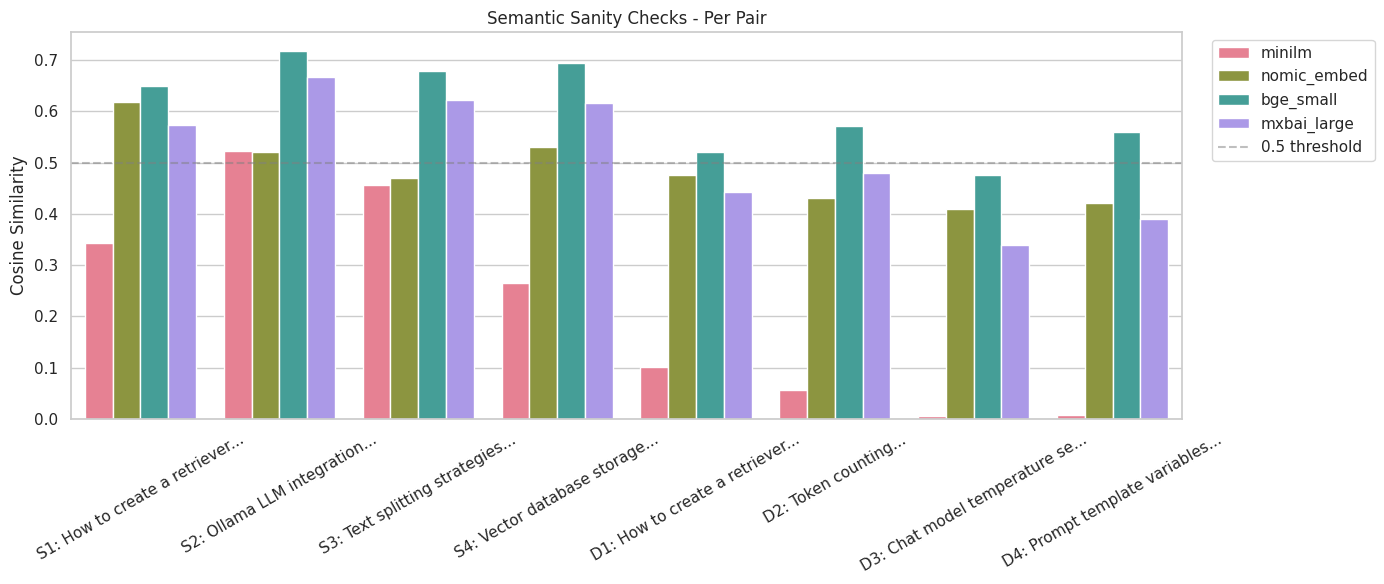

In [8]:
# Detailed per-pair scores
pair_labels_sim = [f"S{i+1}: {a[:25]}..." for i, (a, b) in enumerate(SIMILAR_PAIRS)]
pair_labels_dis = [f"D{i+1}: {a[:25]}..." for i, (a, b) in enumerate(DISSIMILAR_PAIRS)]

detail_data = []
for key, r in sanity_results.items():
    for label, score in zip(pair_labels_sim, r["similar_scores"]):
        detail_data.append({"model": key, "pair": label, "type": "similar", "cosine_sim": score})
    for label, score in zip(pair_labels_dis, r["dissimilar_scores"]):
        detail_data.append({"model": key, "pair": label, "type": "dissimilar", "cosine_sim": score})

detail_df = pd.DataFrame(detail_data)

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(
    data=detail_df,
    x="pair",
    y="cosine_sim",
    hue="model",
    ax=ax,
    palette="husl",
)
ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5, label="0.5 threshold")
ax.set_xlabel("")
ax.set_ylabel("Cosine Similarity")
ax.set_title("Semantic Sanity Checks - Per Pair")
ax.tick_params(axis="x", rotation=30)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

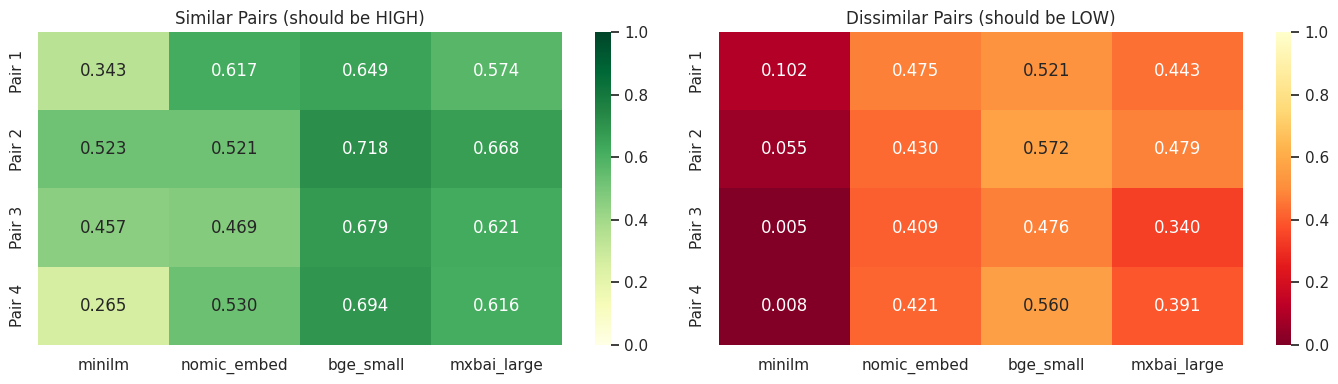

In [9]:
# Separation heatmap: avg_similar - avg_dissimilar per model
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Similar pairs heatmap
sim_matrix = pd.DataFrame(
    {key: r["similar_scores"] for key, r in sanity_results.items()},
    index=[f"Pair {i+1}" for i in range(len(SIMILAR_PAIRS))],
)
sns.heatmap(sim_matrix, annot=True, fmt=".3f", cmap="YlGn", vmin=0, vmax=1, ax=axes[0])
axes[0].set_title("Similar Pairs (should be HIGH)")

# Dissimilar pairs heatmap
dissim_matrix = pd.DataFrame(
    {key: r["dissimilar_scores"] for key, r in sanity_results.items()},
    index=[f"Pair {i+1}" for i in range(len(DISSIMILAR_PAIRS))],
)
sns.heatmap(dissim_matrix, annot=True, fmt=".3f", cmap="YlOrRd_r", vmin=0, vmax=1, ax=axes[1])
axes[1].set_title("Dissimilar Pairs (should be LOW)")

plt.tight_layout()
plt.show()

---
## 5. Retrieval Quality Comparison

For each embedding model, we:
1. Index the full corpus into a temporary ChromaDB collection
2. Run benchmark queries
3. Compare retrieval scores and latency

In [10]:
import chromadb
from langchain_chroma import Chroma

PERSIST_DIR = str(PROJECT_ROOT / "vectorstore" / "chroma_db")


def index_with_model(chunks, embeddings, collection_name, batch_size=500):
    """Index chunks into a ChromaDB collection, return (vectorstore, time, skipped)."""
    client = chromadb.PersistentClient(path=PERSIST_DIR)
    try:
        client.delete_collection(collection_name)
    except Exception:
        pass

    vs = Chroma(
        client=client,
        collection_name=collection_name,
        embedding_function=embeddings,
    )

    skipped = 0
    start = time.perf_counter()
    for i in range(0, len(chunks), batch_size):
        batch = chunks[i : i + batch_size]
        try:
            vs.add_documents(batch)
        except Exception as e:
            # Fallback: try one by one
            for doc in batch:
                try:
                    vs.add_documents([doc])
                except Exception:
                    skipped += 1
    elapsed = time.perf_counter() - start

    return vs, elapsed, skipped


# All models index the same pre-filtered chunks
print(f"Indexing {len(chunks)} chunks (pre-filtered to <={MAX_CHARS} chars) per model.\n")

retrieval_results = {}

for key, m in models.items():
    emb = m["embeddings"]
    info = m["info"]
    coll_name = f"emb_eval_{key}"

    print(f"Indexing with {key} ({info.dimensions}d, {info.provider})...", flush=True)
    vs, index_time, skipped = index_with_model(chunks, emb, coll_name)
    indexed_count = vs._collection.count()
    print(f"  Indexed {indexed_count} chunks in {index_time:.1f}s ({skipped} skipped)")

    bench_df = benchmark_queries(vs, BENCH_QUERIES, k=5)
    bench_df["model"] = key

    retrieval_results[key] = {
        "bench_df": bench_df,
        "index_time_s": round(index_time, 1),
        "indexed_count": indexed_count,
        "skipped": skipped,
    }

    print(f"  Avg top score: {bench_df['top_score'].mean():.4f}")
    print(f"  Avg latency:   {bench_df['latency_ms'].mean():.1f} ms")

print("\nAll models indexed and benchmarked.")

Indexing 9136 chunks (pre-filtered to <=1400 chars) per model.

Indexing with minilm (384d, sentence-transformers)...
  Indexed 9136 chunks in 158.8s (0 skipped)
  Avg top score: 1.1306
  Avg latency:   18.5 ms
Indexing with nomic_embed (768d, ollama)...
  Indexed 9136 chunks in 141.3s (0 skipped)
  Avg top score: 0.5002
  Avg latency:   30.8 ms
Indexing with bge_small (384d, sentence-transformers)...
  Indexed 9136 chunks in 343.1s (0 skipped)
  Avg top score: 0.5377
  Avg latency:   20.5 ms
Indexing with mxbai_large (1024d, ollama)...
  Indexed 9136 chunks in 150.7s (0 skipped)
  Avg top score: 0.6855
  Avg latency:   33.9 ms

All models indexed and benchmarked.


In [11]:
# Combined retrieval summary
all_bench = pd.concat([r["bench_df"] for r in retrieval_results.values()], ignore_index=True)

ret_summary = (
    all_bench.groupby("model")
    .agg(
        avg_top_score=("top_score", "mean"),
        avg_avg_score=("avg_score", "mean"),
        avg_latency_ms=("latency_ms", "mean"),
    )
    .round(4)
)

# Add indexing info
for key in ret_summary.index:
    info = models[key]["info"]
    ret_summary.loc[key, "dimensions"] = info.dimensions
    ret_summary.loc[key, "index_time_s"] = retrieval_results[key]["index_time_s"]

ret_summary["dimensions"] = ret_summary["dimensions"].astype(int)

ret_summary = ret_summary[
    ["dimensions", "avg_top_score", "avg_avg_score", "avg_latency_ms", "index_time_s"]
]

print("Retrieval Quality Summary (5 queries, k=5):")
display(ret_summary)

Retrieval Quality Summary (5 queries, k=5):


,dimensions,avg_top_score,avg_avg_score,avg_latency_ms,index_time_s
model,,,,,
bge_small,384,0.5377,0.5676,20.48,343.1
minilm,384,1.1306,1.2028,18.50,158.8
mxbai_large,1024,0.6855,0.7209,33.88,150.7
nomic_embed,768,0.5002,0.6056,30.84,141.3


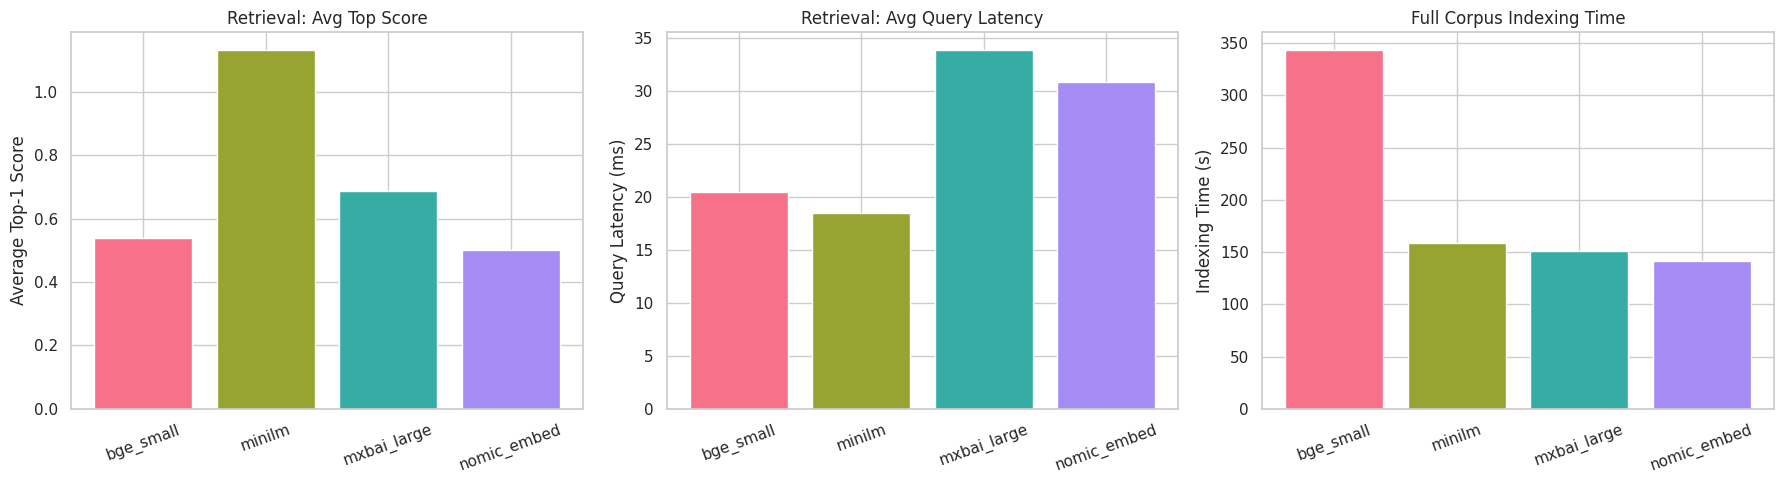

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_order = ret_summary.index.tolist()
colors = sns.color_palette("husl", len(model_order))

# Top score
axes[0].bar(model_order, ret_summary["avg_top_score"], color=colors)
axes[0].set_ylabel("Average Top-1 Score")
axes[0].set_title("Retrieval: Avg Top Score")
axes[0].tick_params(axis="x", rotation=20)

# Latency
axes[1].bar(model_order, ret_summary["avg_latency_ms"], color=colors)
axes[1].set_ylabel("Query Latency (ms)")
axes[1].set_title("Retrieval: Avg Query Latency")
axes[1].tick_params(axis="x", rotation=20)

# Indexing time
axes[2].bar(model_order, ret_summary["index_time_s"], color=colors)
axes[2].set_ylabel("Indexing Time (s)")
axes[2].set_title("Full Corpus Indexing Time")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

---
## 6. Vector Store Size on Disk

We estimate the storage cost per model by measuring the size of the ChromaDB collections
already created in section 5. Since all collections contain the same chunks, the size
difference comes from the embedding dimensions.

In [13]:
# Estimate per-model disk cost from the existing evaluation collections.
# ChromaDB stores all collections in the same sqlite database, so we can't
# measure individual collection sizes directly. Instead, we compute the
# theoretical embedding storage: num_chunks x dimensions x 4 bytes (float32).

disk_results = {}
for key, m in models.items():
    info = m["info"]
    rr = retrieval_results[key]
    n = rr["indexed_count"]

    # Raw embedding bytes (float32 = 4 bytes per dimension)
    embedding_bytes = n * info.dimensions * 4
    # ChromaDB overhead (metadata, indices): roughly 1.3-1.5x raw embeddings
    estimated_mb = (embedding_bytes * 1.4) / (1024 * 1024)

    disk_results[key] = {
        "dimensions": info.dimensions,
        "indexed_chunks": n,
        "embedding_mb": round(embedding_bytes / (1024 * 1024), 1),
        "estimated_total_mb": round(estimated_mb, 1),
    }
    print(f"{key}: {info.dimensions}d x {n} chunks = {embedding_bytes / (1024*1024):.1f} MB embeddings (~{estimated_mb:.1f} MB on disk)")

disk_df = pd.DataFrame(disk_results).T
display(disk_df)

minilm: 384d x 9136 chunks = 13.4 MB embeddings (~18.7 MB on disk)
nomic_embed: 768d x 9136 chunks = 26.8 MB embeddings (~37.5 MB on disk)
bge_small: 384d x 9136 chunks = 13.4 MB embeddings (~18.7 MB on disk)
mxbai_large: 1024d x 9136 chunks = 35.7 MB embeddings (~50.0 MB on disk)


,dimensions,indexed_chunks,embedding_mb,estimated_total_mb
minilm,384.0,9136.0,13.4,18.7
nomic_embed,768.0,9136.0,26.8,37.5
bge_small,384.0,9136.0,13.4,18.7
mxbai_large,1024.0,9136.0,35.7,50.0


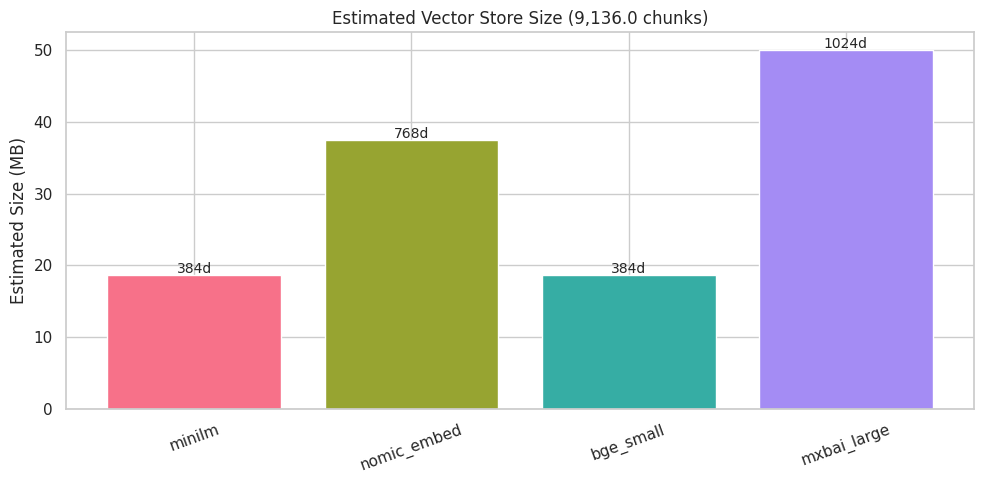

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

disk_models = disk_df.index.tolist()
sizes = disk_df["estimated_total_mb"].values
dims = disk_df["dimensions"].values

bars = ax.bar(disk_models, sizes, color=sns.color_palette("husl", len(disk_models)))

for bar, d in zip(bars, dims):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{int(d)}d",
        ha="center",
        fontsize=10,
    )

ax.set_ylabel("Estimated Size (MB)")
ax.set_title(f"Estimated Vector Store Size ({disk_df['indexed_chunks'].iloc[0]:,} chunks)")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

---
## 7. Overall Comparison

Combined view of all metrics to guide model selection.

In [15]:
# Build a combined comparison table
overall_rows = []
for key in models:
    info = models[key]["info"]
    row = {
        "model": key,
        "provider": info.provider,
        "dimensions": info.dimensions,
    }

    # Throughput
    if key in benchmarks:
        bench = benchmarks[key]
        row["corpus_time_s"] = round(bench.embed_corpus_time_s, 2)
        row["docs_per_sec"] = round(bench.num_documents / bench.embed_corpus_time_s, 1) if bench.embed_corpus_time_s > 0 else 0
        row["query_latency_ms"] = round(bench.avg_query_latency_ms, 1)

    # Sanity checks
    if key in sanity_results:
        row["semantic_separation"] = round(sanity_results[key]["separation"], 4)

    # Retrieval
    if key in retrieval_results:
        bench_df = retrieval_results[key]["bench_df"]
        row["avg_top_score"] = round(float(bench_df["top_score"].mean()), 4)
        row["index_time_s"] = retrieval_results[key]["index_time_s"]

    # Disk
    if key in disk_results:
        row["estimated_mb"] = disk_results[key]["estimated_total_mb"]

    overall_rows.append(row)

overall_df = pd.DataFrame(overall_rows).set_index("model")
print("Overall Embedding Model Comparison:")
display(overall_df)

Overall Embedding Model Comparison:


,provider,dimensions,corpus_time_s,docs_per_sec,query_latency_ms,semantic_separation,avg_top_score,index_time_s,estimated_mb
model,,,,,,,,,
minilm,sentence-transformers,384,8.96,55.8,18.1,0.3545,1.1306,158.8,18.7
nomic_embed,ollama,768,4.58,109.3,61.4,0.1003,0.5002,141.3,37.5
bge_small,sentence-transformers,384,22.19,22.5,17.6,0.1528,0.5377,343.1,18.7
mxbai_large,ollama,1024,7.20,69.4,21.8,0.2066,0.6855,150.7,50.0


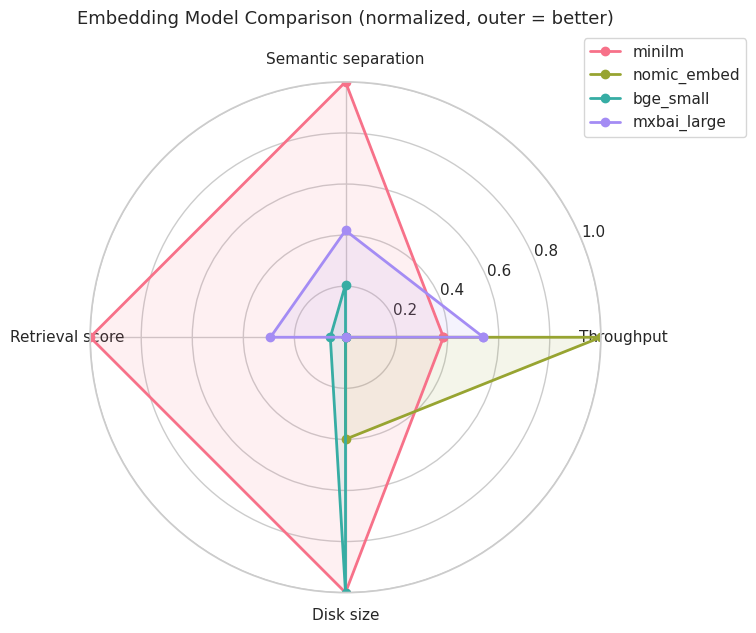

In [16]:
# Normalized radar chart for model comparison
radar_cols = ["docs_per_sec", "semantic_separation", "avg_top_score", "estimated_mb"]
radar_labels = ["Throughput", "Semantic separation", "Retrieval score", "Disk size"]
# For each column, normalize to [0, 1]. For disk size, invert (smaller = better)
radar_data = overall_df[radar_cols].copy()

for col in radar_cols:
    col_min, col_max = radar_data[col].min(), radar_data[col].max()
    if col_max > col_min:
        radar_data[col] = (radar_data[col] - col_min) / (col_max - col_min)
    else:
        radar_data[col] = 0.5

# Invert disk size (lower is better)
radar_data["estimated_mb"] = 1 - radar_data["estimated_mb"]

# Radar plot
angles = np.linspace(0, 2 * np.pi, len(radar_cols), endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = sns.color_palette("husl", len(radar_data))

for i, (model_name, row) in enumerate(radar_data.iterrows()):
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, "o-", linewidth=2, label=model_name, color=colors[i])
    ax.fill(angles, values, alpha=0.1, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title("Embedding Model Comparison (normalized, outer = better)", fontsize=13, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

---
## 8. Cleanup Evaluation Collections

In [17]:
client = chromadb.PersistentClient(path=PERSIST_DIR)
existing = [c.name for c in client.list_collections()]

eval_collections = [c for c in existing if c.startswith("emb_eval_")]
print(f"Removing {len(eval_collections)} evaluation collections...")
for name in eval_collections:
    client.delete_collection(name)
    print(f"  Deleted: {name}")

print(f"\nRemaining collections: {[c.name for c in client.list_collections()]}")

Removing 4 evaluation collections...
  Deleted: emb_eval_mxbai_large
  Deleted: emb_eval_minilm
  Deleted: emb_eval_nomic_embed
  Deleted: emb_eval_bge_small

Remaining collections: ['sensitivity_cs500', 'sensitivity_cs1500', 'sensitivity_cs750', 'chunking_eval_recursive', 'chunking_eval_markdown', 'course_qa_naive', 'chunking_eval_token', 'sensitivity_cs1000', 'chunking_eval_fixed']


---
## 9. Save Results

In [18]:
results_output = {
    "corpus": {
        "total_chunks_before_filter": len(all_chunks),
        "dropped_by_char_filter": dropped_chars,
        "dropped_by_token_validation": token_dropped,
        "chunks_after_filter": len(chunks),
        "max_chars_limit": MAX_CHARS,
    },
    "models": {},
    "benchmark_queries": BENCH_QUERIES,
    "similar_pairs": SIMILAR_PAIRS,
    "dissimilar_pairs": DISSIMILAR_PAIRS,
}

for key in models:
    info = models[key]["info"]
    entry = {
        "provider": info.provider,
        "model_id": info.model_id,
        "dimensions": info.dimensions,
        "max_tokens": info.max_tokens,
        "max_chars": info.max_chars,
        "description": info.description,
    }

    if key in benchmarks:
        bench = benchmarks[key]
        entry["throughput"] = {
            "sample_size": len(sample_texts),
            "embedded_count": bench.num_documents,
            "corpus_time_s": round(bench.embed_corpus_time_s, 2),
            "docs_per_sec": round(bench.num_documents / bench.embed_corpus_time_s, 1) if bench.embed_corpus_time_s > 0 else 0,
            "avg_query_latency_ms": round(bench.avg_query_latency_ms, 1),
        }

    if key in sanity_results:
        sr = sanity_results[key]
        entry["semantic_sanity"] = {
            "avg_similar": round(sr["avg_similar"], 4),
            "avg_dissimilar": round(sr["avg_dissimilar"], 4),
            "separation": round(sr["separation"], 4),
            "similar_scores": [round(s, 4) for s in sr["similar_scores"]],
            "dissimilar_scores": [round(s, 4) for s in sr["dissimilar_scores"]],
        }

    if key in retrieval_results:
        rr = retrieval_results[key]
        bench_df = rr["bench_df"]
        entry["retrieval"] = {
            "avg_top_score": round(float(bench_df["top_score"].mean()), 4),
            "avg_avg_score": round(float(bench_df["avg_score"].mean()), 4),
            "avg_latency_ms": round(float(bench_df["latency_ms"].mean()), 1),
            "index_time_s": rr["index_time_s"],
            "indexed_count": rr["indexed_count"],
        }

    if key in disk_results:
        entry["disk"] = disk_results[key]

    results_output["models"][key] = entry

# Save
results_dir = PROJECT_ROOT / "results"
results_dir.mkdir(exist_ok=True)
output_path = results_dir / "embeddings_comparison.json"

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(results_output, f, indent=2, ensure_ascii=False)

print(f"Results saved to {output_path}")

Results saved to /home/hunganh/Code/Python/course_qa_assist/results/embeddings_comparison.json


## 10. Summary & Observations

### Results at a glance
| Model | Throughput | Query latency | Separation | Retrieval top-1 | Indexing | Disk |
|-------|-----------|---------------|------------|-----------------|---------|------|
| **minilm** | 55.8 docs/s | 18.1 ms | **0.355** | 1.131 | 158.8 s | 18.7 MB |
| **nomic_embed** | **109.3 docs/s** | 61.4 ms | 0.100 | 0.500 | **141.3 s** | 37.5 MB |
| **bge_small** | 22.5 docs/s | **17.6 ms** | 0.153 | 0.538 | 343.1 s | 18.7 MB |
| **mxbai_large** | 69.4 docs/s | 21.8 ms | 0.207 | 0.686 | 150.7 s | **50.0 MB** |

### Key findings on the current corpus

**1. Corpus filtering was minimal.**
We started with 9,137 chunks and dropped only 1 during token validation. The shared max chars limit is 1,400 to keep all models comparable.

**2. Retrieval scores are not comparable across models.**
ChromaDB similarity scores differ by embedding scale and normalization. Use the separation metric and latency as more reliable cross-model signals.

**3. Semantic separation favors MiniLM and MxBAI.**
- **MiniLM (0.355)** shows the strongest separation in the sanity checks.
- **MxBAI-large (0.207)** is second best and more consistent for technical language.
- **BGE-small (0.153)** and **Nomic (0.100)** separate less on this corpus.

**4. Throughput vs latency trade-off is real.**
- **Nomic** embeds the sample fastest (109.3 docs/s) but has the slowest query latency (61.4 ms).
- **BGE-small** and **MiniLM** have the lowest query latency (17.6 ms and 18.1 ms).
- **MxBAI-large** sits in the middle on speed but is largest on disk (~50 MB).

**Recommendation:** If you prioritize overall quality and can afford the disk cost, use `mxbai-embed-large`.
If you need small and fast, `minilm` or `bge_small` are good defaults. `nomic-embed-text` is best when batch throughput matters most.
